# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

### Understanding the structure of the data

In [ ]:
# read the data
df = pd.read_csv('/content/drive/MyDrive/MIT/Week 1/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
print("Number of rows:",df.shape[0]) # shape is an atribute of a pandas DataFrame
print("Number of columns:",df.shape[1])

Number of rows: 1898
Number of columns: 9


#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
'rating' is expected to be a numeric variable.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
print("Number of Null Values:", df.isnull().sum()) # Return true or false for NaN values in each row and sum for each column

Number of Null Values: order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


In [ ]:
# We can also check for duplicated rows
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


#### Observations:
There is no missing data or duplicate rows



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Checking for all statistics of the data
df.describe().T # .T to enhance reading

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


In [ ]:
df.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

In [ ]:
print("Preparing Food:")
print("Minimum Time:", df["food_preparation_time"].min())
print("Maximum Time:", df["food_preparation_time"].max())
print("Average Time:", round(df["food_preparation_time"].mean(),2))

Preparing Food:
Minimum Time: 20
Maximum Time: 35
Average Time: 27.37


#### Observations:
Preparing Food Time (minutes):

Minimum: 20

Maximum: 35

Average: 27.37


### **Question 5:** How many orders are not rated? [1 mark]

*   Item da lista
*   Item da lista



In [ ]:
not_rated_orders = df['rating'].loc[df['rating'] == 'Not given']
print("Number of orders not rated:", not_rated_orders.count())

Number of orders not rated: 736


#### Observations:
**736 orders** were not rated.


### Exploratory Data Analysis (EDA)

In [ ]:
# Before further analysis we can include a new column to help with insights
# Total order time (prep + delivery time)
df['total_order_time'] = df['food_preparation_time'] + df['delivery_time']

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

<Axes: title={'center': 'Rating Distribution'}, xlabel='rating', ylabel='Count'>

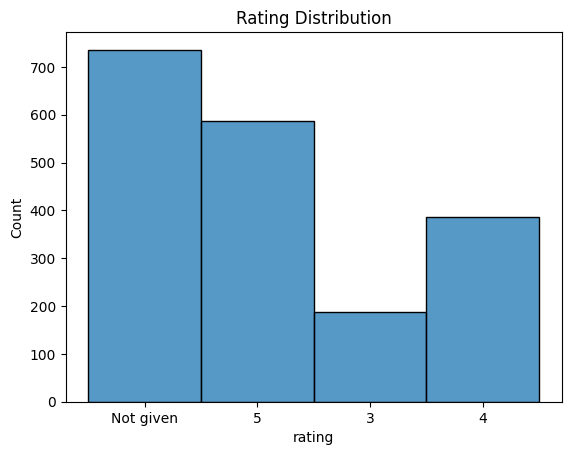

In [ ]:
plt.title('Rating Distribution')

sns.histplot(df['rating'])

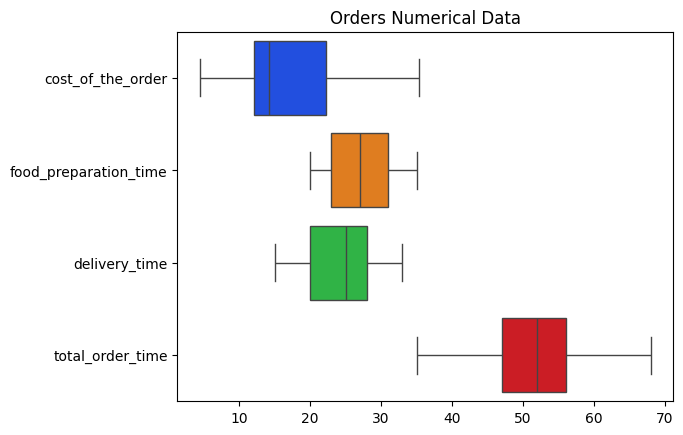

In [ ]:
plt.title('Orders Numerical Data')
sns.boxplot(
    data=df[['cost_of_the_order',
        'food_preparation_time',
        'delivery_time',
        'total_order_time',
        ]],
    orient='h',
    palette='bright'
    )
plt.show()

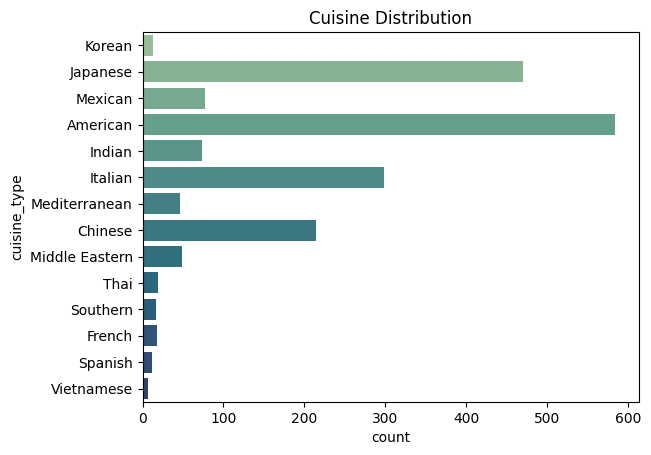

In [ ]:
plt.title('Cuisine Distribution')

sns.countplot(data=df['cuisine_type'], palette='crest')
plt.show()

In [ ]:
def assign_loyalty_category(orders):
    if orders == 1:
        return "New"
    elif 2 <= orders <= 5:
        return "Casual"
    elif 6 <= orders <= 8:
        return "Frequent"
    else:
        return "VIP"

In [ ]:
customers_freq = df.groupby(['customer_id'])['order_id'].count() # Counting orders by customer_id
customers_df = pd.DataFrame(customers_freq) # Converting to pandas DataFrame to make it easier to interact
df.reset_index()
customers_df.columns = ['number_of_orders'] # Labeling the created column

# Creating new column "loyalty_category" to rotulate customers frequency
customers_df['fidelity'] = customers_df['number_of_orders'].apply(assign_loyalty_category)
customers_df.head()

,number_of_orders,fidelity
customer_id,,
1311,1,New
5139,1,New
5444,1,New
5693,1,New
6987,2,Casual


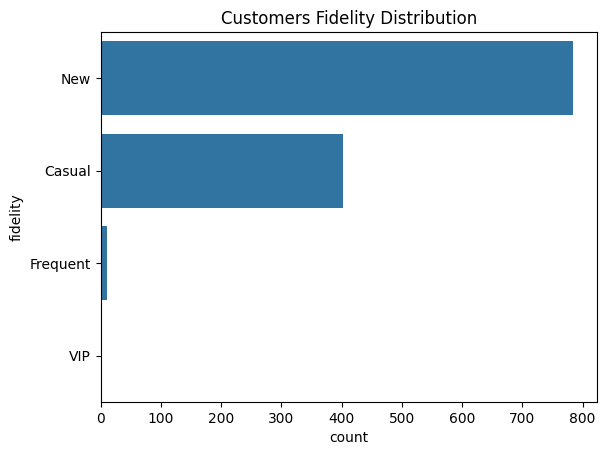

In [ ]:
# Counting and comparing each kind of customer
plt.title('Customers Fidelity Distribution')
order = ["New", "Casual", "Frequent", "VIP"]
sns.countplot(data=customers_df['fidelity'], order=order)
plt.show()

In [ ]:
american_count = df['cuisine_type'].loc[df['cuisine_type'] == 'American'].count()
japanese_count = df['cuisine_type'].loc[df['cuisine_type'] == 'Japanese'].count()
total_count = df['cuisine_type'].count()
most_orders_proportion = (american_count/total_count)*100
print(round(most_orders_proportion, 1))

30.8


#### Observations:
## Rating
Looking at rating's the distribution, we can see that a lot of customers are choosing not to rate the order

## Box Plots
Analysing the boxplot, we can see that there are **no outliers** on this Data Frame.
Also, the total order time has a way greater delta then the other time columns. This could be an indicative that there is **delay** between the time the order is ready and the time the order leaves the restaurant
## Cuisine
The 'cuisine_type' distribution shows us that **30.8%** of total orders are either American or Japanese cuisines

##Customers
Analyzing the new fidelity categories, we observe that **most customers are new** (they have placed only one order). This suggests either a high influx of new customers or that first-time buyers are not returning for additional purchases. Suggestion: to make more clear that those are new customers or non-recurrent customers, compute the datetime when each customer registered

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
top_rest = df.groupby(['restaurant_name'])['order_id'].count().sort_values(ascending=False)
print(top_rest.head())

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: order_id, dtype: int64


In [ ]:
# How much those orders represents from the total?
total_orders = top_rest.sum()
top_rest_orders = 0
for restaurant in range(0, 5):
  top_rest_orders += top_rest[restaurant]
top_rest_orders_proportion = (top_rest_orders/total_orders)*100
print(round(top_rest_orders_proportion, 1))


33.4


In [ ]:
# How much of the top 5 restaurant orders were made on weekends?
pop_rest_list = ['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi', 'Blue Ribbon Fried Chicken', 'Parm']
pop_rest_orders_weekend = 0

weekend_orders = df.loc[df['day_of_the_week'] == 'Weekend']
pop_weekend_orders = weekend_orders.groupby(['restaurant_name'])['order_id'].count()

for restaurant in pop_rest_list:
  pop_rest_orders_weekend += pop_weekend_orders[restaurant]

pop_weekend_rest_orders_proportion = (pop_rest_orders_weekend/top_rest_orders)*100
print(round(pop_weekend_rest_orders_proportion, 1))

69.6


#### Observations:
Top 5 n_orders Restaurants:
1. Shake Shack   -->   219
2. The Meatball Shop      -->     132
3. Blue Ribbon Sushi       -->     119
4. Blue Ribbon Fried Chicken  -->   96
5. Parm                 -->         68

**69.6%** of those orders were made on weekends

Total orders from the most popular restaurants represent **33.4%** of all orders on all days.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
pop_weekend_cuisines = weekend_orders.groupby(['cuisine_type'])['order_id'].count().sort_values(ascending=False)
pop_weekend_cuisines.head(3)

,order_id
cuisine_type,
American,415
Japanese,335
Italian,207


In [ ]:
# How much this represents from the total of orders made on weekend?
total_weekend_orders = pop_weekend_cuisines.sum()
american_weekend_orders = pop_weekend_cuisines[0]
american_weekend_orders_proportion = (american_weekend_orders/total_weekend_orders)*100
print(round(american_weekend_orders_proportion, 1))

30.7


#### Observations:

'**American**' is the most popular cuisine on weekends with **415 orders**, representing **30.7%** of all weekend orders.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
more_than_20usd_orders = df['cost_of_the_order'].loc[df['cost_of_the_order'] > 20].count()
more_than_20usd_orders_proportion = (more_than_20usd_orders/total_orders)*100
print(round(more_than_20usd_orders_proportion, 1))

29.2


#### Observations:
**29.2%** of the total orders cost more than $20

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
delivery_time_mu = df['delivery_time'].mean()
print(round(delivery_time_mu, 2))

24.16


#### Observations:
Orders have an average delivery time of **24.16 minutes**.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
most_freq_customers = df.groupby(['customer_id'])['order_id'].count().sort_values(ascending=False)
most_freq_customers.head(3)

,order_id
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The most frequent customers are:
1. **52832**	with **13** orders
2. **47440**	with **10** orders
3. **83287**	with **9** orders

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
 9   total_order_time       1898 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 148.4+ KB


In [ ]:
# Remove 'Not given' from rating for better analysis
df_rating = df.loc[df['rating'] != 'Not given']
# Cast rating to integer
df_rating['rating'] = df_rating['rating'].astype(int)
df_rating.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 2 to 1896
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1162 non-null   int64  
 1   customer_id            1162 non-null   int64  
 2   restaurant_name        1162 non-null   object 
 3   cuisine_type           1162 non-null   object 
 4   cost_of_the_order      1162 non-null   float64
 5   day_of_the_week        1162 non-null   object 
 6   rating                 1162 non-null   int64  
 7   food_preparation_time  1162 non-null   int64  
 8   delivery_time          1162 non-null   int64  
 9   total_order_time       1162 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 99.9+ KB


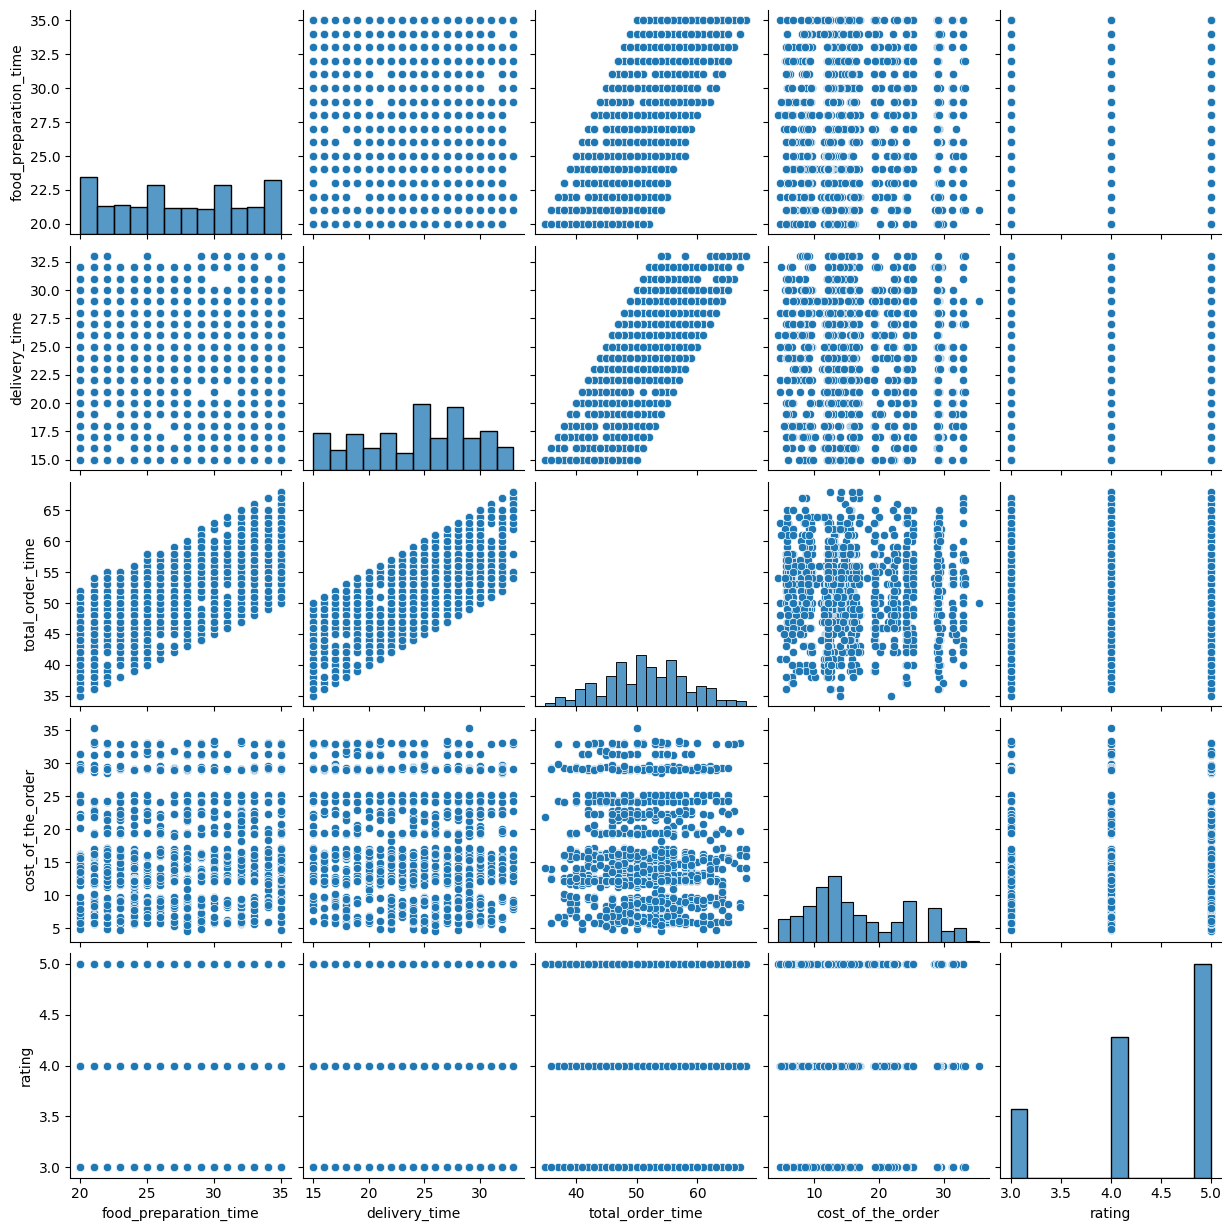

In [ ]:
# Pair plot to check for correlations between numerical variables (only rated orders)
sns.pairplot(data=df_rating[["food_preparation_time", "delivery_time", "total_order_time", "cost_of_the_order", "rating"]])
plt.show()

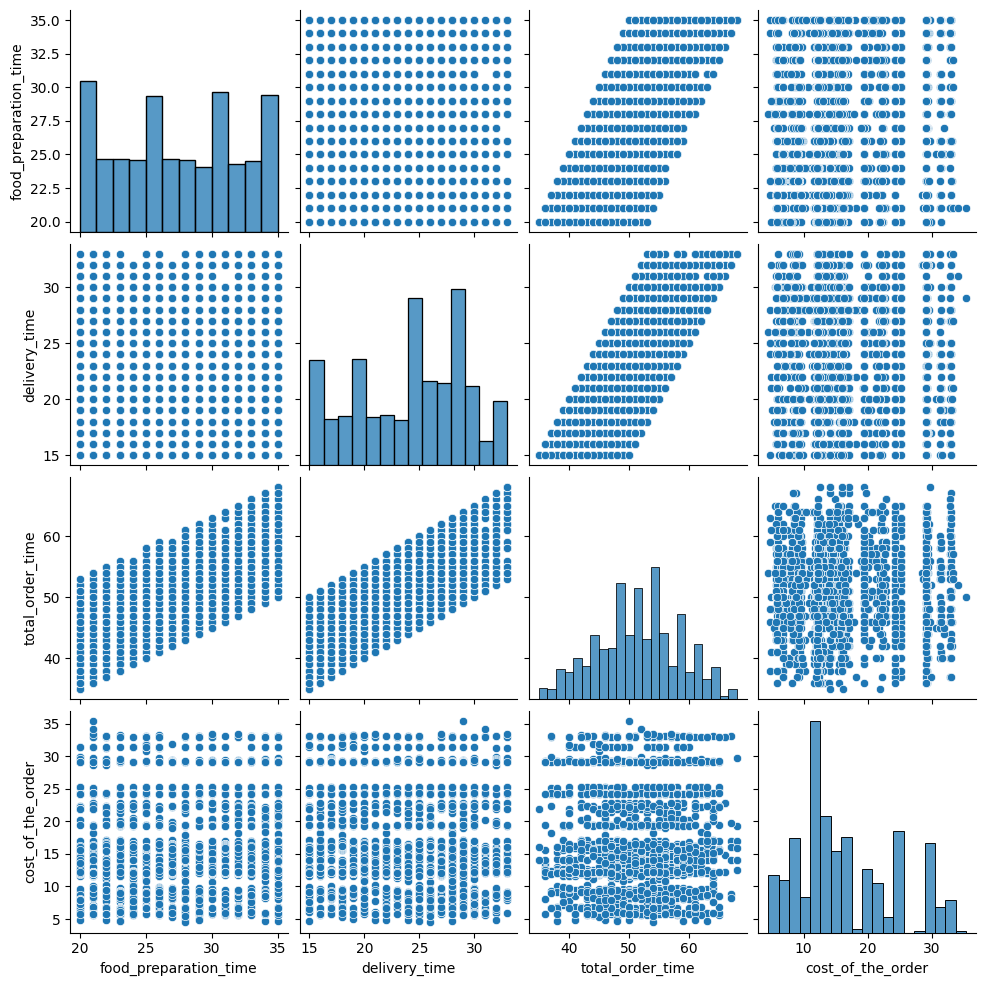

In [ ]:
# Checking if the missing rows made any difference in the analysis (all orders)
sns.pairplot(data=df[["food_preparation_time", "delivery_time", "total_order_time", "cost_of_the_order", "rating"]])

<Axes: title={'center': 'Rated Orders Correlation Heat Map'}>

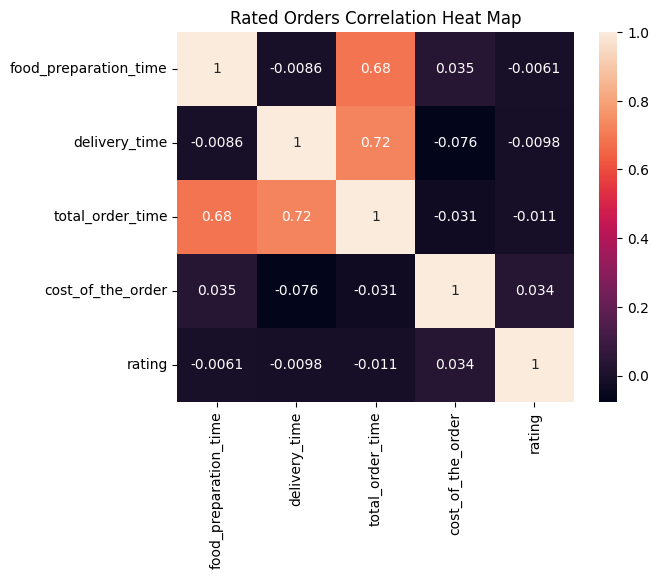

In [ ]:
# Heat maps are also a good way to look for correlation between numerical variables
plt.title('Rated Orders Correlation Heat Map')
sns.heatmap(df_rating[["food_preparation_time", "delivery_time", "total_order_time", "cost_of_the_order", "rating"]].corr(), annot=True)
# Since there's no sign of relevant correlation in both cases, there's no need to repeate the heat map for unrated orders

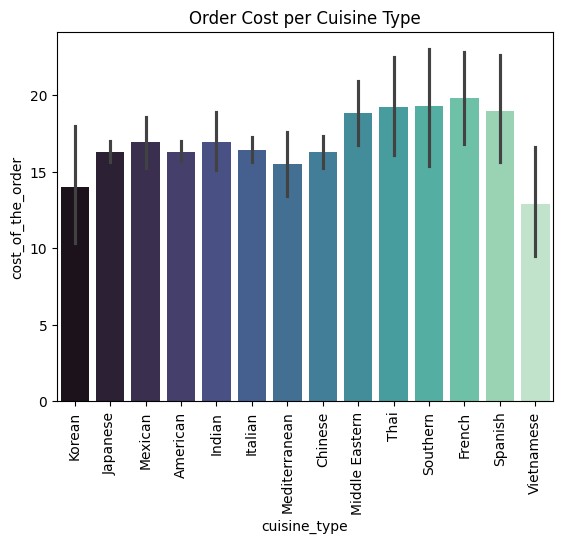

In [ ]:
# Checking order cost for each cuisine type
plt.title('Order Cost per Cuisine Type')
sns.barplot(x=df['cuisine_type'], y=df['cost_of_the_order'], palette='mako')
plt.xticks(rotation=90)
plt.show()

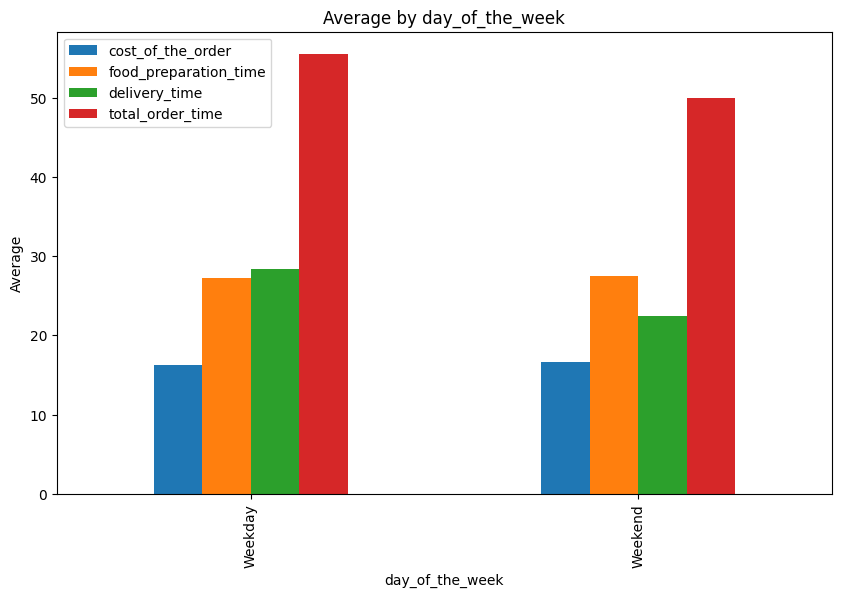

In [ ]:
# Numeric variables avg by day_of_the_week
avg_per_day = df.groupby('day_of_the_week')[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'total_order_time']].mean()
avg_per_day.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Average')
plt.title('Average by day_of_the_week')
plt.show()


<Axes: title={'center': 'Order Cost by day_of_the_week'}, xlabel='day_of_the_week', ylabel='cost_of_the_order'>

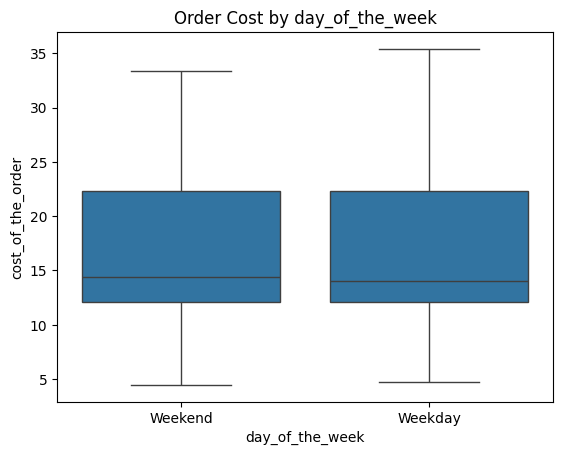

In [ ]:
# Checking for difference on the order cost by 'day_of_the_week'
plt.title('Order Cost by day_of_the_week')
sns.boxplot(data=df, y='cost_of_the_order', x='day_of_the_week')

####Observations
There's not much correlation between the variables.

We can notice that the **'delivery_time' decreases on the weekends**, probabily because of traffic. Total order time increses by the same rate of the delivery time.

It's also noticeble that the highest cost order happened on the weekday, but that's not really and indicator

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
rest_rating = df_rating.groupby(['restaurant_name'])['rating'].agg(['count', 'mean'])
rest_rating = rest_rating.loc[(rest_rating['count'] > 50) & (rest_rating['mean'] > 4)]
rest_rating.head()

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:
There are only 4 elegible restaurants:

Blue Ribbon Fried Chicken

Blue Ribbon Sushi

Shake Shack

The Meatball Shop


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Calculate revenue for 'cost_of_the_order' > 5$ and <= $20
greater_5p_lower_20p = df.loc[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]
revenue_5p = greater_5p_lower_20p['cost_of_the_order'].sum() * 0.15
print(round(revenue_5p, 2))

2477.58


In [ ]:
# Calculate revenue for 'cost_of_the_order' > $20
greater_20p = df.loc[df['cost_of_the_order'] > 20]
revenue_20p = greater_20p['cost_of_the_order'].sum() * 0.25
print(round(revenue_20p, 2))

3688.73


In [ ]:
# Calculate company's total revenue
total_revenue = revenue_5p + revenue_20p
print(round(total_revenue, 2))

6166.3


#### Observations:
The company generated **$6166.30** in revenue across all orders

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Using the already created column 'total_order_time'
total_orders = df['order_id'].count()
orders_count_60min = df.loc[df['total_order_time'] > 60].count()['order_id']
order_60min_percentile = orders_count_60min/total_orders
print(round(order_60min_percentile * 100,2))

10.54


#### Observations:
**10.54%** of the orders took more than 60 minutes to be delivered


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
weekdays_delivery_avg = df.loc[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()
weekends_delivery_avg = df.loc[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()
print('Weekdays:', round(weekdays_delivery_avg, 2))
print('Weekends:', round(weekends_delivery_avg, 2))
difference_avg = weekdays_delivery_avg - weekends_delivery_avg
print('Average Difference:', round(difference_avg, 2))

Weekdays: 28.34
Weekends: 22.47
Average Difference: 5.87


#### Observations:
Delivery time increases on average **5.87 minutes** on weekdays.

#### Testing a hypothesis: If we charge less for higher cost orders and more for lower cost ones, do we have an increase on revenue?

Null Hypothesis: **μd <= 0**

Alternate Hypothesis: **μd > 0**

In [ ]:
# Filter orders: Only consider orders where cost >= $5 (since commission rules start at $5)
df_greater_5usd = df[df['cost_of_the_order'] >= 5].copy()

In [ ]:
def current_commission_model(x):
  if(x > 20):
    return x * 0.25
  else:
    return x * 0.15

def alternative_commission_model(x):
  if(x > 20):
    return x * 0.15
  else:
    return x * 0.25

In [ ]:
# Current commission model:
# 25% for orders > $20
# 15% for orders between $5 and $20
df_greater_5usd['current_commission'] = df_greater_5usd['cost_of_the_order'].apply(current_commission_model)


In [ ]:
# Alternative commission model (flipped rates):
# 15% for orders > $20
# 25% for orders between $5 and $20
df_greater_5usd['alternative_commission'] = df_greater_5usd['cost_of_the_order'].apply(alternative_commission_model)


In [ ]:
# Compute total revenue for each commission model
total_current_revenue = df_greater_5usd['current_commission'].sum()
total_alternative_revenue = df_greater_5usd['alternative_commission'].sum()

print("\nTotal Revenue Under Each Model:")
print(f"Current Model Revenue: ${round(total_current_revenue, 2)}")
print(f"Alternative Model Revenue: ${round(total_alternative_revenue, 2)}")


Total Revenue Under Each Model:
Current Model Revenue: $6166.3
Alternative Model Revenue: $6342.53


In [ ]:
df_greater_5usd['commission_diff'] = df_greater_5usd['alternative_commission'] - df_greater_5usd['current_commission']

In [ ]:
# Paired t-test: Tests whether the mean difference is significantly different from 0.
t_stat, p_value = stats.ttest_rel(df_greater_5usd['alternative_commission'], df_greater_5usd['current_commission'])
print("\nPaired t-test Results:")
print(f"t-value: {round(t_stat,4)}")
print(f"p-value: {round(p_value, 4)}")


Paired t-test Results:
t-value: 2.2356
p-value: 0.0255


According to the t student table the critical t-value is '~1.65' for this sample size.

The calculated t-value is actually greater than the critical t-value, indicating we should reject the null hypothesis.

Now we should construct the **95%** confidence interval.

**Upper bound = Xd_bar + tc * sd/sqrt(n)**

**Lower bound = Xd_bar - tc * sd/sqrt(n)**


Where: Xd_bar -> difference avg

tc -> critical t-value

sd/sqrt(n) -> std error


In [ ]:
# Calculating the standard deviation, standard error and 'xd_bar'
std_dev_differences = df_greater_5usd['commission_diff'].std()
print(f"Standard Deviation of Differences: ${round(std_dev_differences, 2)}")
sample_size = len(df_greater_5usd)
print(f"Sample Size: {sample_size}")
std_error = std_dev_differences / np.sqrt(sample_size)
print(f"Standard Error: {round(std_error, 4)}")
xd_bar = df_greater_5usd['commission_diff'].mean()
print(f"Difference Average: {round(xd_bar, 4)}")

Standard Deviation of Differences: $1.81
Sample Size: 1889
Standard Error: 0.0417
Difference Average: 0.0933


In [ ]:
# Calculate the Confidence Interval (CI)
upper_bound = xd_bar + 1.65 * std_error
lower_bound = xd_bar - 1.65 * std_error
print(f"Lower Bound: {round(lower_bound, 4)}")
print(f"Upper Bound: {round(upper_bound, 4)}")

Lower Bound: 0.0244
Upper Bound: 0.1621


We are <ins>95% confident</ins> that mean difference is between **0.0244 and 0.1621**.

This is strong evidence that we should <ins>reject the null hypothesis</ins>

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* There is <ins>strong evidence</ins> that changing the commission model will **increase revenue**.
* There is not much correlation between the variables.
* A large percentage of orders were not rated, which may indicate a lack of customer engagement with the rating system.
* Most customers only placed **one order**, highlighting a possible challenge in customer retention.
* There might be a gap between the time the food is ready and when it leaves for delivery. Possibly causing **delays**.
* Delivery time **decreases on weekends**.
* **One third** of the orders are related to the top 5 restaurants.
* Most of the orders made on popular restaurants **happened on weekends**.
* American and Japanese cuisines account for **30.8%** of all orders, making them the most popular categories.

### Recommendations:
* Changing the commisison model by charging less on high-value orders potentially increase revenue. This also encourages restaurants to increase the average cost per order;

*  Computing the datetime when the customers registered. This way we can know if we're having high influx of new customers or if the majority of the customers don't make new orders.

* Customers should be encouraged more to rate orders, since a lot of them are not rating;

* We should measure the time the food waits for the delivery person to get it. It's good to know if there's a delay at this moment, to see if we are able to enhance 'total_order_time
'


---